In [1]:
# 1. Importação de bibliotecas
# 2. Carregamento dos dados
# 3. Criar métricas por aeroporto
# 4. Preparação e limpeza dos dados
# 5. Transformação de log e cria variaveis para o modelo.
# 6. Padronização dos dados (feature scaling)
# 7. Aplica o PCA e Redução de dimensionalidade (PCA)
# 8. Cria o modelo de Clusterização (K-Means)
# 9. Visualização do Cluster
# 10. O Silhouette Score
# 11. Entendimento do perfil médio de cada cluster
# 12. Mapa com o aeroporto com maior atraso médio
# 13. Atraso médio por cluster
# 14. Clusterização de aeroportos por volume de voos e atraso
# 15 -Alta complexidade Operacional OCI
# 16. Gráfico com os TOP 10 mais criticos Aeroportos
# 17. Mapa com os Aeroportos mais critícos pelo OCI.

#1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [2]:
#2 - Carregar os dados
df_flights = pd.read_csv(r"C:\Users\gerem\Desktop\Tech_challenge_3_M_Supervisionados_N_Supervisionados\data\flights.csv")
airports = pd.read_csv(r"C:\Users\gerem\Desktop\Tech_challenge_3_M_Supervisionados_N_Supervisionados\data\airports.csv")

C:\Users\gerem\AppData\Local\Temp\ipykernel_18644\650671033.py:2: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df_flights = pd.read_csv(r"C:\Users\gerem\Desktop\Tech_challenge_3_M_Supervisionados_N_Supervisionados\data\flights.csv")


In [6]:
#3 Criar métricas por aeroporto.
df = df_flights[
[
"ORIGIN_AIRPORT",
"DEPARTURE_DELAY",
"DISTANCE"
]].dropna()

airport_stats = df.groupby("ORIGIN_AIRPORT").agg(
    total_flights=("DISTANCE","count"),
    avg_delay=("DEPARTURE_DELAY","mean"),
    delay_std=("DEPARTURE_DELAY","std"),
    avg_distance=("DISTANCE","mean")
).reset_index()

In [7]:
# 4. Preparação e limpeza dos dados
airport_stats = airport_stats[airport_stats["total_flights"] > 2000]

# Esse filtro remove aeroportos muito pequenos, que geralmente:
# têm poucos voos
# geram muito ruído estatístico
# pioram a clusterização
# Isso ajuda o algoritmo a focar em aeroportos relevantes.
# Cuidado, dependendo do dataset, você pode remover todos os dados.

airport_stats["log_flights"] = np.log1p(airport_stats["total_flights"])

airport_stats = airport_stats.dropna()
# Remover aeroportos pequenos e criar transformação log.
#print("Antes do filtro:", len(airport_stats))

In [8]:
#5 Transformação de log e cria variaveis para o modelo.
# Usar log no volume de voos, distribuição de voos costuma ser assimetrica.f
airport_stats["log_flights"] = np.log1p(airport_stats["total_flights"]) #aplica o log porque os valores são muito desbalanceados.
# airport_stats = airport_stats.dropna()

features = airport_stats[
[
"log_flights",
"avg_delay",
"delay_std",
"avg_distance"
]]

In [9]:
# Verificar o tamanho do frame, apenas para saber se os registros foram filtrados.
print(airport_stats.shape)
print(features.shape)

(232, 6)
(232, 4)


In [10]:
# 6. Padronização dos dados (feature scaling)
# Essa função do scikit-learn transforma as variáveis para que todas fiquem na mesma escala estatística, normaliza os dados.
#Ela aplica a fórmula:

# x = valor original
# μ = média da variável
# σ = desvio padrão

# Resultado:
# propriedade	valor
# média	≈ 0
# desvio padrão	≈ 1

# Antes da padronização:

# aeroporto	flights	delay
# A	10000	10
# B	2000	5

# Depois do StandardScaler:

# aeroporto	flights_scaled	delay_scaled
# A	1.2  0.8
# B	-0.9  -0.3

# Agora todas as variáveis tem peso semelhante.

scaler = StandardScaler()

X_scaled = scaler.fit_transform(features)

Variância explicada: [0.42345774 0.40563424]


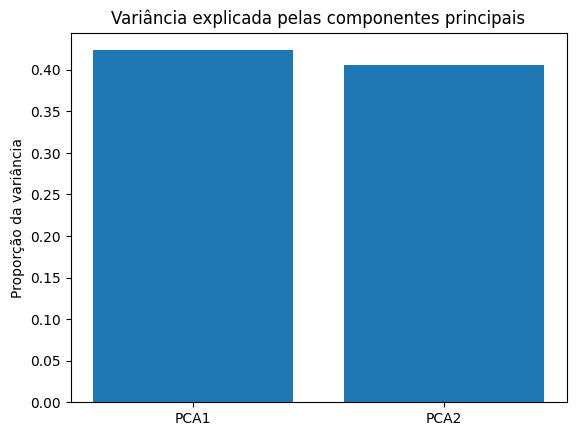

In [11]:
# 7. Aplica o PCA e Redução de dimensionalidade (PCA)
# Esse trecho aplica PCA (Principal Component Analysis) aos seus dados escalados para reduzir a dimensionalidade e facilitar a visualização e a clusterização.
# O PCA (Análise de Componentes Principais) é uma técnica que:
# transforma várias variáveis em novos eixos
# mantém a maior parte da informação dos dados
# reduz a dimensionalidade
# Esse projeto tinha variáveis como:
# log_flights
# avg_delay
# delay_std
# avg_distance
# Essas 4 variáveis viram apenas 2 novas variáveis.

pca = PCA(n_components=2)
# Essa linha cria um modelo PCA que vai gerar 2 componentes principais. Reduzir o dataset para 2 dimensões.

X_pca = pca.fit_transform(X_scaled)
# Essa linha executa duas etapas:
# fit()
# O PCA analisa o dataset e calcula:
# direção de maior variância
# segunda direção de maior variância
# transform()
# Ele projeta os dados nesses novos eixos.

# O Resultado é uma nova matriz com duas colunas:

# | PCA1  | PCA2  |
# | ----- | ----- |
# | 0.52  | -0.11 |
# | -1.32 | 0.85  |
# | 2.41  | 1.09  |

# Componente	significado
# PCA1	direção de maior variabilidade dos aeroportos
# PCA2	segunda maior variabilidade

# No seu caso, o PCA provavelmente está capturando algo como:
# PCA1
# relacionado com:
# volume de voos
# complexidade operacional
# PCA2
# relacionado com:
# atraso médio
# variabilidade de atraso

print("Variância explicada:", pca.explained_variance_ratio_)
plt.bar(["PCA1","PCA2"], pca.explained_variance_ratio_)
plt.title("Variância explicada pelas componentes principais")
plt.ylabel("Proporção da variância")

plt.show()

# Quando você aplica PCA, o algoritmo cria novos eixos (componentes principais) que capturam a maior variação possível dos dados.
# Cada componente explica uma parte da variabilidade total do dataset.

# componente	variância explicada
# PCA1	42% da informação
# PCA2	40% da informação
# 42% + 40% = 82%
# 82% da informação dos dados originais foi preservada em apenas 2 dimensões.
# Isso é considerado muito bom.

In [12]:
# 8. Cria o modelo de Clusterização (K-Means)
kmeans = KMeans(n_clusters=3, random_state=42)

airport_stats["cluster"] = kmeans.fit_predict(X_pca)

# Cria o modelo K-Means
# Aqui você está configurando o algoritmo de clusterização.
# Parâmetros importantes:
# parâmetro	significado
# n_clusters=3	o algoritmo vai dividir os dados em 3 grupos
# random_state=42	garante que o resultado seja reproduzível

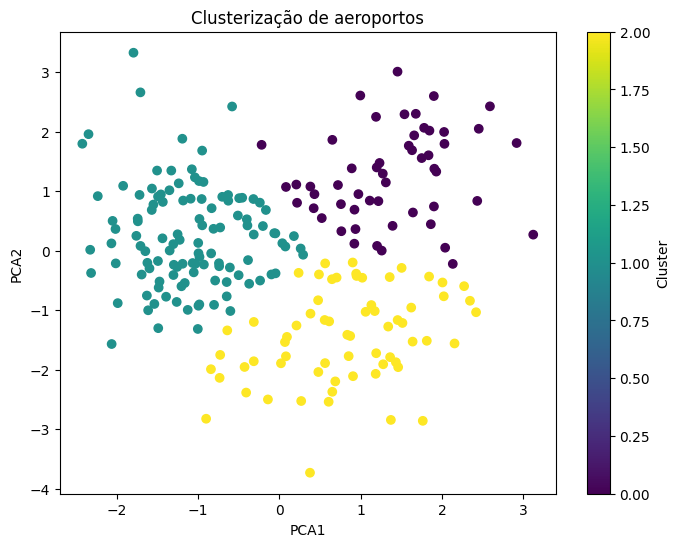

In [13]:
# 9. Visualização do Cluster
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0], #resultado do PCA / Primeira coluna.
    X_pca[:,1],
    c=airport_stats["cluster"], # Cada ponto recebe uma cor baseado no cluster.
    cmap="viridis" # Define o mapa de cores usando grafico, cada cluster recebe uma cor diferente.
)
# Essa função do Matplotlib cria um gráfico de pontos.
# Cada ponto representa uma observação do seu dataset.
# Nesse caso cada ponto é um Aeroporto.
# PCA1 é a primeira componente principal, que representa a maior variação dos dados.
# PCA2 é a segunda componente principal.
# Depois da clusterização, cada cluster geralmente representa um tipo de aeroporto.
# Exemplo comum:
# cluster	interpretação
# 0	aeroportos regionais
# 1	aeroportos médios
# 2	hubs principais

plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("Clusterização de aeroportos")

plt.colorbar(label="Cluster")

plt.show()

# Esse gráfico mostra:
# aeroportos com características semelhantes ficam próximos
# aeroportos com características diferentes ficam distantes
# cada grupo representa um tipo de aeroporto

# Exemplo:

# cluster	possível interpretação
# 0	aeroportos regionais
# 1	aeroportos médios
# 2	hubs principais

In [14]:
# 10. O Silhouette Score
score = silhouette_score(X_pca, airport_stats["cluster"])

print("Silhouette Score:", score)

# Ele usa a métrica chamada Silhouette Score, muito comum para avaliar modelos de clusterização (não supervisionados).
# O Silhouette Score mede duas coisas ao mesmo tempo:
# Quão perto um ponto está dos pontos do mesmo cluster
# Quão distante ele está dos outros clusters
# Ou seja, ele mede qualidade da separação entre clusters.

Silhouette Score: 0.4474966569944673


Silhouette Score: 0.4474966569944673


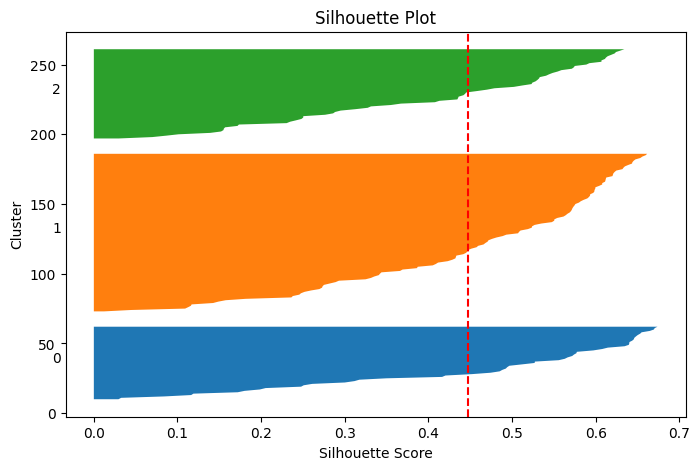

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_samples, silhouette_score

# Labels já existentes
labels = airport_stats["cluster"]

# Score médio
silhouette_avg = silhouette_score(X_pca, labels)
print("Silhouette Score:", silhouette_avg)

# Score por ponto
sample_silhouette_values = silhouette_samples(X_pca, labels)

y_lower = 10
n_clusters = len(np.unique(labels))

plt.figure(figsize=(8, 5))

for i in range(n_clusters):
    ith_cluster_values = sample_silhouette_values[labels == i]
    ith_cluster_values.sort()
    
    size_cluster_i = ith_cluster_values.shape[0]
    y_upper = y_lower + size_cluster_i
    
    plt.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_cluster_values)
    
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    
    y_lower = y_upper + 10

# Linha média
plt.axvline(x=silhouette_avg, color="red", linestyle="--")

plt.xlabel("Silhouette Score")
plt.ylabel("Cluster")
plt.title("Silhouette Plot")
plt.show()

In [16]:
# 11. Entendimento do perfil médio de cada cluster
airport_stats.groupby("cluster")[[
"total_flights",
"avg_delay",
"delay_std"
]].mean()
# Mostra perfil médio a cada cluster, ajuda a entender o tamanho de cada grupo.
# Cluster 0 - Grandes hubs (alta complexidade) - muito mais voos que os outros, atraso relativamente alto, grande variabilidade de atraso.
# métrica	valor 
# voos <-> 77k #atraso médio <-> 9.94 min #variabilidade <-> atraso	37.3
# Cluster 1 - Aeroportos médios com atraso instável. - Menos voos, Atraso médio moderado, maior variabilidade de atraso.
# métrica	valor
# voos <-> 5,746 # atraso médio <->	8.04 #variabilidade atraso <-> 43.3 (maior)
# Cluster 2 - Aeroportos eficientes - volume moderado de voos, menor atraso médio, menor variabilidade.
# métrica	valor
# voos <-> 10,756 #atraso médio <->	4.31 (menor) #variabilidade atraso <-> 29.7 (menor)


,total_flights,avg_delay,delay_std
cluster,,,
0,78510.207547,10.001065,37.328877
1,5767.561404,8.055735,43.319259
2,10475.384615,4.255247,29.511364


In [17]:
airport_stats = airport_stats.merge(
    airports,
    left_on="ORIGIN_AIRPORT",
    right_on="IATA_CODE"
)
# Combinando duas tabelas usando uma chave em comum.

In [18]:
pip install folium

   ---------------------------------------- 0.0/113.4 kB ? eta -:--:--
   ---------------------------------------  112.6/113.4 kB 3.2 MB/s eta 0:00:01
   ---------------------------------------- 113.4/113.4 kB 1.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/93.9 kB ? eta -:--:--
   ---------------------------------------- 93.9/93.9 kB 5.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.3.1 -> 26.0.1
[notice] To update, run: C:\Users\gerem\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [19]:
airport_stats = airport_stats.dropna(subset=["LATITUDE","LONGITUDE"])
# Isso remove apenas os aeroportos que não tem posição geográfica.

In [20]:
# 12. Mapa com o aeroporto com maior atraso médio
import folium

# identificar pior aeroporto
worst_airport = airport_stats.loc[airport_stats["avg_delay"].idxmax()]

m = folium.Map(location=[39.5, -98.35], zoom_start=4)

max_delay = airport_stats["avg_delay"].max()

for _, row in airport_stats.iterrows():

    # cores dos clusters
    if row["cluster"] == 0:
        color = "blue"
    elif row["cluster"] == 1:
        color = "green"
    elif row["cluster"] == 2:
        color = "orange"
    else:
        color = "gray"

    # se for o pior aeroporto → vermelho
    if row["ORIGIN_AIRPORT"] == worst_airport["ORIGIN_AIRPORT"]:
        color = "red"

    radius = (row["avg_delay"] / max_delay) * 25

    folium.CircleMarker(
        location=[row["LATITUDE"], row["LONGITUDE"]],
        radius=radius,
        popup=f"""
        Airport: {row['ORIGIN_AIRPORT']} <br>
        Avg Delay: {row['avg_delay']:.2f} min <br>
        Flights: {row['total_flights']} <br>
        Cluster: {row['cluster']}
        """,
        color=color,
        fill=True,
        fill_opacity=0.7
    ).add_to(m)

m

In [21]:
# elemento visual	significado
# 🔵 azul	cluster 0
# 🟢 verde	cluster 1
# 🟠 laranja	cluster 2
# 🔴 vermelho	aeroporto com maior atraso médio
# tamanho da bolha	atraso médio

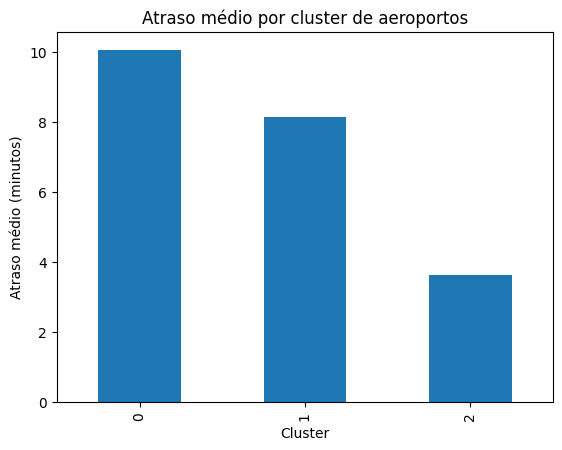

In [22]:
# 13. Atraso médio por cluster
import matplotlib.pyplot as plt

cluster_delay = airport_stats.groupby("cluster")["avg_delay"].mean()

cluster_delay.plot(kind="bar")

plt.title("Atraso médio por cluster de aeroportos")
plt.xlabel("Cluster")
plt.ylabel("Atraso médio (minutos)")

plt.show()

In [23]:
airport_stats["cluster"].value_counts()

cluster
1    108
0     51
2     24
Name: count, dtype: int64

In [24]:
worst_airport = airport_stats.loc[airport_stats["avg_delay"].idxmax()]


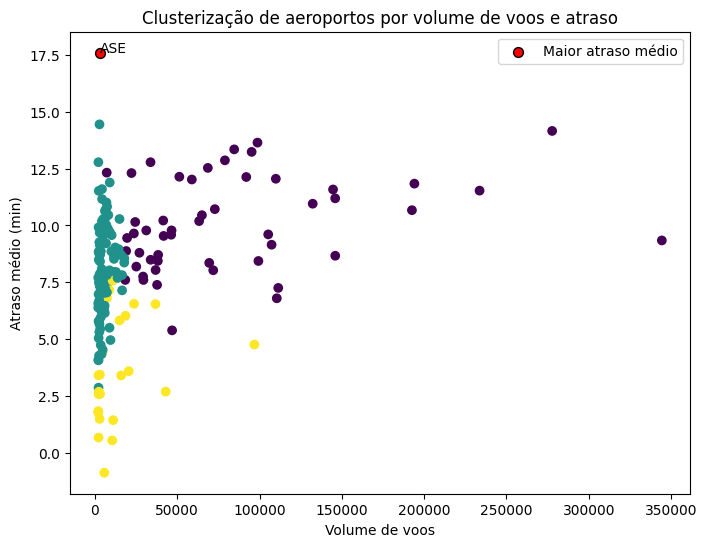

In [25]:
# 14. Clusterização de aeroportos por volume de voos e atraso
plt.figure(figsize=(8,6))

plt.scatter(
    airport_stats["total_flights"],
    airport_stats["avg_delay"],
    c=airport_stats["cluster"],
    cmap="viridis"
)

# destacar o aeroporto com maior atraso
plt.scatter(
    worst_airport["total_flights"],
    worst_airport["avg_delay"],
    color="red",
    s=50,
    edgecolor="black",
    label="Maior atraso médio"
)

plt.text(
    worst_airport["total_flights"],
    worst_airport["avg_delay"],
    worst_airport["ORIGIN_AIRPORT"],
    fontsize=10,
    ha="left"
)

plt.xlabel("Volume de voos")
plt.ylabel("Atraso médio (min)")
plt.title("Clusterização de aeroportos por volume de voos e atraso")

plt.legend()

plt.show()

In [26]:
# # O que é o aeroporto ASE
# # ASE é o código IATA de:
# # Aspen / Pitkin County Airport
# # Localização:
# # Aspen, Colorado – EUA

# # 1 - Características importantes:

# # fator	impacto
# # aeroporto em montanha	aproximação difícil
# # pista curta	limita aeronaves
# # clima severo	neve e vento
# # aeroporto pequeno	pouca redundância operacional
# # Esses fatores geram maior probabilidade de atraso.

# # 2. Geografia (principal fator)
# # Aspen fica nas Montanhas Rochosas.
# # Problemas comuns:
# # aproximações complexas
# # terreno elevado
# # turbulência

# # Isso aumenta: delay, go-around, cancelamentos
# Condições meteorológicas
# Aspen tem: neve frequente, visibilidade reduzida, ventos de montanha.
# Isso impacta: DEPARTURE_DELAY, ARRIVAL_DELAY

# Infraestrutura limitada
# ASE tem: pista relativamente curta, poucos slots, capacidade limitada
# Se um voo atrasa, pode gerar efeito cascata.

In [27]:
# 15 -Alta complexidade Operacional OCI
from sklearn.preprocessing import StandardScaler

vars_oci = airport_stats[[
    "total_flights",
    "avg_delay",
    "delay_std"
]]

scaler = StandardScaler()
vars_scaled = scaler.fit_transform(vars_oci)

airport_stats["OCI"] = (
    vars_scaled[:,0] +
    vars_scaled[:,1] +
    vars_scaled[:,2]
)

In [28]:
# Os 10 mais criticos
top_critical = airport_stats.sort_values("OCI", ascending=False).head(10)

top_critical[[
    "ORIGIN_AIRPORT",
    "CITY",
    "total_flights",
    "avg_delay",
    "delay_std",
    "OCI"
]]

,ORIGIN_AIRPORT,CITY,total_flights,avg_delay,delay_std,OCI
133,ORD,Chicago,277748,14.151375,40.662407,7.167585
10,ATL,Atlanta,344384,9.340695,32.940019,5.615150
9,ASE,Aspen,3290,17.587538,54.925116,5.103774
49,DFW,Dallas-Fort Worth,233658,11.528820,36.308279,4.679789
176,TTN,Trenton,2784,14.440374,57.143326,4.358641
172,STT,Charlotte Amalie,4301,11.596140,60.156245,3.885562
48,DEN,Denver,194077,11.836019,35.368765,3.839740
101,LGA,New York,95204,13.231398,43.111289,3.565566
33,CHO,Charlottesville,2111,12.777830,55.434205,3.497955
97,LAX,Los Angeles,192585,10.669969,35.423108,3.415152


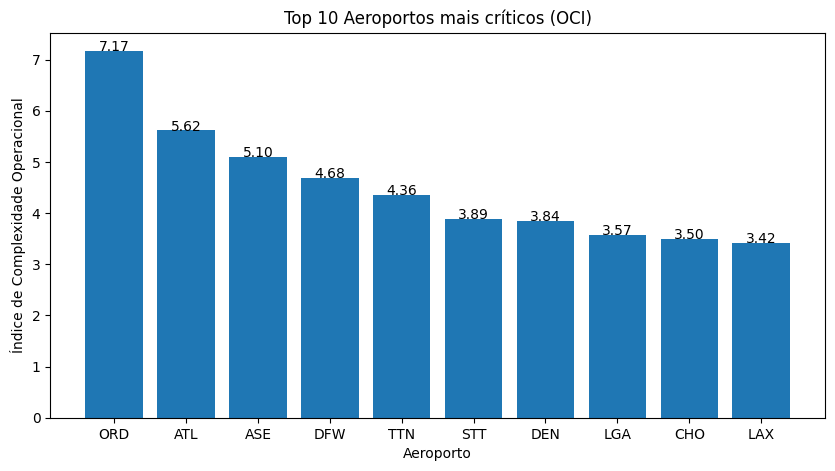

In [29]:
# 16. Gráfico com os TOP 10 mais criticos Aeroportos
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    top_critical["ORIGIN_AIRPORT"],
    top_critical["OCI"]
)

plt.title("Top 10 Aeroportos mais críticos (OCI)")
plt.xlabel("Aeroporto")
plt.ylabel("Índice de Complexidade Operacional")

# adicionar valores
for i, v in enumerate(top_critical["OCI"]):
    plt.text(i, v, f"{v:.2f}", ha="center")

plt.show()

In [30]:
# Alta complexidade Operacional -> Maior risco de atraso.
#Cluster 0 → hubs grandes → alto OCI
#Cluster 1 → aeroportos instáveis → médio OCI
#Cluster 2 → aeroportos eficientes → baixo OCI

In [31]:
top_critical = airport_stats.sort_values("OCI", ascending=False).head(10)

top_critical[[
    "ORIGIN_AIRPORT",
    "CITY",
    "total_flights",
    "avg_delay",
    "delay_std",
    "OCI"
]]

,ORIGIN_AIRPORT,CITY,total_flights,avg_delay,delay_std,OCI
133,ORD,Chicago,277748,14.151375,40.662407,7.167585
10,ATL,Atlanta,344384,9.340695,32.940019,5.615150
9,ASE,Aspen,3290,17.587538,54.925116,5.103774
49,DFW,Dallas-Fort Worth,233658,11.528820,36.308279,4.679789
176,TTN,Trenton,2784,14.440374,57.143326,4.358641
172,STT,Charlotte Amalie,4301,11.596140,60.156245,3.885562
48,DEN,Denver,194077,11.836019,35.368765,3.839740
101,LGA,New York,95204,13.231398,43.111289,3.565566
33,CHO,Charlottesville,2111,12.777830,55.434205,3.497955
97,LAX,Los Angeles,192585,10.669969,35.423108,3.415152


In [32]:
airport_stats = airport_stats.dropna(subset=["LATITUDE","LONGITUDE"])

In [33]:
# 17. Mapa com os Aeroportos mais critícos pelo OCI.
import folium

m = folium.Map(location=[39.5, -98.35], zoom_start=4)

# definir limites
p90 = airport_stats["OCI"].quantile(0.90)
p70 = airport_stats["OCI"].quantile(0.70)

for _, row in airport_stats.iterrows():

    # definir cor por criticidade
    if row["OCI"] >= p90:
        color = "red"       # crítico
        radius = 12
        nivel = "Crítico"

    elif row["OCI"] >= p70:
        color = "orange"    # médio
        radius = 8
        nivel = "Médio"

    else:
        color = "green"     # normal
        radius = 5
        nivel = "Normal"

    folium.CircleMarker(
        location=[row["LATITUDE"], row["LONGITUDE"]],
        radius=radius,
        popup=f"""
        Airport: {row['ORIGIN_AIRPORT']}<br>
        OCI: {row['OCI']:.2f}<br>
        Delay: {row['avg_delay']:.2f}<br>
        Nível: {nivel}
        """,
        color=color,
        fill=True,
        fill_opacity=0.7
    ).add_to(m)

m